# ASCON-AEAD-128 Tight-Trigger Key-Byte Dataset Collection

This notebook collects ASCON-AEAD-128 key-byte tight-trigger traces in the same overall style as the ACORNv3 dataset collection.

Default target:

```text
30,000 traces per byte
16 bytes total
480,000 traces total
```

Expected ASCON firmware folder:

```text
C:\Users\thetp\Downloads\ASCON_FYP\01_Firmware\tight_trigger_keybyte\simpleserial-ascon-keyabsorb
```

Expected SimpleSerial commands:

```text
k <16 bytes> : send ASCON key
n <16 bytes> : send ASCON nonce
p <1 byte>   : capture selected target key byte, 0 to 15
e <16 bytes> : optional full encryption sanity test
r            : receive response
```

Run order:

1. Configuration
2. Inspect firmware and `.hex` file
3. Connect and flash firmware
4. Test SimpleSerial commands
5. Run a small capture sanity check
6. Collect 30,000 traces per byte
7. Verify saved dataset

In [1]:
# Cell 1 - Configuration

from pathlib import Path
from datetime import datetime
import time
import json
import gc
import os
import re
import shutil
import subprocess

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# ============================================================
# Project paths
# ============================================================
PROJECT_DIR = Path(r"C:\Users\thetp\Downloads\ASCON_FYP")
FW_DIR = PROJECT_DIR / "01_Firmware" / "tight_trigger_keybyte" / "simpleserial-ascon-keyabsorb"
HEX_PATH = FW_DIR / "simpleserial-ascon-keyabsorb-CWLITEXMEGA.hex"

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_ROOT = PROJECT_DIR / "03_Data" / "tight_trigger_keybyte_auto30k"
OUT_DIR = OUT_ROOT / f"ascon_tighttrigger_30k_per_byte_{RUN_ID}"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# ChipWhisperer / capture settings
# ============================================================
PLATFORM = "CWLITEXMEGA"
SS_VER = "SS_VER_1_1"
TRACE_LEN = 2000
ADC_TIMEOUT = 5

# ============================================================
# ASCON settings
# ============================================================
KEY_LEN = 16
NONCE_LEN = 16
TARGET_BYTE_LEN = 1
RESP_LEN_KEYBYTE = 1
TEST_PLAINTEXT_LEN = 16
TEST_CIPHERTEXT_LEN = 32  # 16-byte ciphertext + 16-byte tag

# For clean first ASCON experiment, keep nonce fixed and key random.
# Later you may set RANDOM_NONCE_PER_TRACE = True for a harder/more general dataset.
RANDOM_NONCE_PER_TRACE = False
FIXED_NONCE = bytes([0x00] * NONCE_LEN)

# ============================================================
# Dataset size
# ============================================================
TEST_MODE = False

N_TRACES_PER_BYTE_TEST = 100
N_TRACES_PER_BYTE_FULL = 30_000

CHUNK_SIZE_TEST = 100
CHUNK_SIZE_FULL = 1000

TARGET_BYTES_TEST = [0]
TARGET_BYTES_FULL = list(range(16))

if TEST_MODE:
    N_TRACES_PER_BYTE = N_TRACES_PER_BYTE_TEST
    CHUNK_SIZE = CHUNK_SIZE_TEST
    TARGET_BYTES = TARGET_BYTES_TEST
else:
    N_TRACES_PER_BYTE = N_TRACES_PER_BYTE_FULL
    CHUNK_SIZE = CHUNK_SIZE_FULL
    TARGET_BYTES = TARGET_BYTES_FULL

# Resume mode skips already saved chunks and continues collection from existing metadata count.
RESUME_EXISTING = True

# Safety option. Keep False for real collection.
DRY_RUN_NO_SAVE = False

print("PROJECT_DIR:", PROJECT_DIR)
print("FW_DIR:", FW_DIR)
print("HEX_PATH:", HEX_PATH)
print("OUT_DIR:", OUT_DIR)
print("TEST_MODE:", TEST_MODE)
print("N_TRACES_PER_BYTE:", N_TRACES_PER_BYTE)
print("CHUNK_SIZE:", CHUNK_SIZE)
print("TARGET_BYTES:", TARGET_BYTES)
print("RANDOM_NONCE_PER_TRACE:", RANDOM_NONCE_PER_TRACE)

PROJECT_DIR: C:\Users\thetp\Downloads\ASCON_FYP
FW_DIR: C:\Users\thetp\Downloads\ASCON_FYP\01_Firmware\tight_trigger_keybyte\simpleserial-ascon-keyabsorb
HEX_PATH: C:\Users\thetp\Downloads\ASCON_FYP\01_Firmware\tight_trigger_keybyte\simpleserial-ascon-keyabsorb\simpleserial-ascon-keyabsorb-CWLITEXMEGA.hex
OUT_DIR: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\tight_trigger_keybyte_auto30k\ascon_tighttrigger_30k_per_byte_20260526_014007
TEST_MODE: False
N_TRACES_PER_BYTE: 30000
CHUNK_SIZE: 1000
TARGET_BYTES: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
RANDOM_NONCE_PER_TRACE: False


In [2]:
# Cell 2 - Inspect ASCON firmware folder and compiled hex file

if not FW_DIR.exists():
    raise FileNotFoundError(f"Firmware folder not found: {FW_DIR}")

print("Files in firmware folder:")
for p in sorted(FW_DIR.iterdir()):
    print(" -", p.name)

required_files = [
    FW_DIR / "api.h",
    FW_DIR / "encrypt.c",
    FW_DIR / "simpleserial-ascon-keyabsorb.c",
    FW_DIR / "Makefile",
]

missing = [str(p) for p in required_files if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required firmware files:\n" + "\n".join(missing))

if not HEX_PATH.exists():
    raise FileNotFoundError(
        f"Compiled .hex file not found:\n{HEX_PATH}\n\n"
        "Compile the firmware first, then run this notebook again."
    )

print("\nCompiled hex found:", HEX_PATH)
print("Hex size bytes:", HEX_PATH.stat().st_size)

print("\nSimpleSerial / trigger inspection:")
for cfile in [FW_DIR / "simpleserial-ascon-keyabsorb.c", FW_DIR / "encrypt.c"]:
    print("\n===", cfile.name, "===")
    text = cfile.read_text(errors="ignore").splitlines()
    for i, line in enumerate(text, start=1):
        if (
            "simpleserial_addcmd" in line
            or "simpleserial_put" in line
            or "trigger_high" in line
            or "trigger_low" in line
            or "ascon_keybyte_absorb_tighttrigger" in line
        ):
            print(f"{i:04d}: {line}")

print("\nExpected commands:")
print(" - k command accepts 16-byte key")
print(" - n command accepts 16-byte nonce")
print(" - p command accepts 1-byte target byte")
print(" - e command accepts 16-byte plaintext for optional full encryption sanity check")
print(" - r response returns 1 byte for p, 32 bytes for e")

Files in firmware folder:
 - api.h
 - encrypt.c
 - Makefile
 - objdir-CWLITEXMEGA
 - README_TIGHT_TRIGGER_ASCON.md
 - simpleserial-ascon-keyabsorb-CWLITEXMEGA.bin
 - simpleserial-ascon-keyabsorb-CWLITEXMEGA.eep
 - simpleserial-ascon-keyabsorb-CWLITEXMEGA.elf
 - simpleserial-ascon-keyabsorb-CWLITEXMEGA.hex
 - simpleserial-ascon-keyabsorb-CWLITEXMEGA.lss
 - simpleserial-ascon-keyabsorb-CWLITEXMEGA.map
 - simpleserial-ascon-keyabsorb-CWLITEXMEGA.sym
 - simpleserial-ascon-keyabsorb.c

Compiled hex found: C:\Users\thetp\Downloads\ASCON_FYP\01_Firmware\tight_trigger_keybyte\simpleserial-ascon-keyabsorb\simpleserial-ascon-keyabsorb-CWLITEXMEGA.hex
Hex size bytes: 33129

SimpleSerial / trigger inspection:

=== simpleserial-ascon-keyabsorb.c ===
0063:     result = ascon_keybyte_absorb_tighttrigger(key, nonce, target_byte);
0065:     simpleserial_put('r', 1, &result);
0081:     trigger_high();
0095:     trigger_low();
0101:     simpleserial_put('r', TEST_CIPHERTEXT_LEN, ciphertext);
0117:     si

In [3]:
# Cell 3 - Connect to ChipWhisperer and flash ASCON firmware

import chipwhisperer as cw

# Disconnect previous sessions if any.
for obj_name in ["target", "scope"]:
    if obj_name in globals():
        try:
            globals()[obj_name].dis()
        except Exception:
            pass

time.sleep(1)

scope = cw.scope()
target = cw.target(scope)

scope.default_setup()
scope.adc.samples = TRACE_LEN
scope.adc.timeout = ADC_TIMEOUT

print("Connected to ChipWhisperer.")
print("ADC samples:", scope.adc.samples)
print("ADC timeout:", scope.adc.timeout)
print("Flashing firmware:", HEX_PATH)

cw.program_target(scope, cw.programmers.XMEGAProgrammer, str(HEX_PATH))

time.sleep(1)
try:
    target.flush()
except Exception:
    pass

print("ASCON firmware flashed successfully.")

C:\Users\thetp\anaconda3\envs\cw\lib\site-packages\chipwhisperer\capture\trace\TraceWhisperer.py:31: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources # type: ignore


scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 14688088                  to 55966856                 
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 96000000                  to 29538459                 
scope.clock.adc_rate                     changed from 96000000.0                to 29538459.0               
scope.clock.clkgen_

In [4]:
# Cell 4 - Helper functions for SimpleSerial and capture

import time
import re
import numpy as np


def flush_target(delay=0.01):
    try:
        target.flush()
    except Exception:
        pass
    time.sleep(delay)


def random_bytes(n):
    return bytes(np.random.randint(0, 256, size=n, dtype=np.uint8).tolist())


def byte_bits_lsb(byte_val):
    return [(int(byte_val) >> b) & 1 for b in range(8)]


def key_byte_from_key(key_bytes, target_byte):
    return int(key_bytes[int(target_byte)])


def set_key(key_bytes, delay=0.015):
    assert len(key_bytes) == KEY_LEN
    flush_target(0.003)
    target.simpleserial_write('k', bytearray(key_bytes))
    time.sleep(delay)
    try:
        _ = target.read(timeout=0.03)
    except Exception:
        pass


def set_nonce(nonce_bytes, delay=0.015):
    assert len(nonce_bytes) == NONCE_LEN
    flush_target(0.003)
    target.simpleserial_write('n', bytearray(nonce_bytes))
    time.sleep(delay)
    try:
        _ = target.read(timeout=0.03)
    except Exception:
        pass


def read_response_raw(resp_len, timeout_s=0.5, debug=False):
    """Read a SimpleSerial v1 style r response by scanning raw target output."""
    chunks = []
    start = time.time()
    pattern = r"r([0-9a-fA-F]{" + str(resp_len * 2) + r"})"

    while time.time() - start < timeout_s:
        try:
            s = target.read(timeout=0.02)
            if s:
                chunks.append(str(s))
                joined = "".join(chunks)
                m = re.search(pattern, joined)
                if m:
                    return bytes.fromhex(m.group(1)), joined
        except Exception:
            pass
        time.sleep(0.003)

    joined = "".join(chunks)
    if debug:
        print("Raw joined:", repr(joined))
    return None, joined


def get_trigger_count():
    try:
        return int(scope.adc.trig_count)
    except Exception:
        return None


def capture_ascon_keybyte_trace(target_byte, key_bytes=None, nonce_bytes=None, timeout=0.5, debug=False):
    assert 0 <= int(target_byte) <= 15

    if key_bytes is None:
        key_bytes = random_bytes(KEY_LEN)
    if nonce_bytes is None:
        nonce_bytes = random_bytes(NONCE_LEN) if RANDOM_NONCE_PER_TRACE else FIXED_NONCE

    assert len(key_bytes) == KEY_LEN
    assert len(nonce_bytes) == NONCE_LEN

    key_byte_value = key_byte_from_key(key_bytes, target_byte)
    bits = byte_bits_lsb(key_byte_value)

    set_key(key_bytes, delay=0.015)
    set_nonce(nonce_bytes, delay=0.015)

    flush_target(0.002)
    scope.arm()
    target.simpleserial_write('p', bytearray([int(target_byte)]))
    capture_ret = scope.capture()

    out, raw_text = read_response_raw(RESP_LEN_KEYBYTE, timeout_s=timeout, debug=debug)

    try:
        wave = np.asarray(scope.get_last_trace(), dtype=np.float32)
    except Exception:
        wave = None

    trig = get_trigger_count()

    return {
        "wave": wave,
        "out": out,
        "raw_text": raw_text,
        "capture_ret": bool(capture_ret),
        "trig": trig,
        "key_bytes": key_bytes,
        "nonce_bytes": nonce_bytes,
        "key_byte_value": key_byte_value,
        "key_byte_hex": f"{key_byte_value:02x}",
        "key_byte_hw": int(bin(key_byte_value).count("1")),
        "bits": bits,
    }


def run_full_encrypt_sanity(key_bytes=None, nonce_bytes=None, plaintext=None, timeout=1.0, debug=False):
    if key_bytes is None:
        key_bytes = bytes(range(16))
    if nonce_bytes is None:
        nonce_bytes = bytes([0] * 16)
    if plaintext is None:
        plaintext = bytes([0] * 16)

    assert len(key_bytes) == KEY_LEN
    assert len(nonce_bytes) == NONCE_LEN
    assert len(plaintext) == TEST_PLAINTEXT_LEN

    set_key(key_bytes, delay=0.015)
    set_nonce(nonce_bytes, delay=0.015)

    flush_target(0.002)
    scope.arm()
    target.simpleserial_write('e', bytearray(plaintext))
    capture_ret = scope.capture()

    out, raw_text = read_response_raw(TEST_CIPHERTEXT_LEN, timeout_s=timeout, debug=debug)

    try:
        wave = np.asarray(scope.get_last_trace(), dtype=np.float32)
    except Exception:
        wave = None

    trig = get_trigger_count()

    return {
        "out": out,
        "raw_text": raw_text,
        "capture_ret": bool(capture_ret),
        "wave": wave,
        "trig": trig,
        "key_hex": key_bytes.hex(),
        "nonce_hex": nonce_bytes.hex(),
        "plaintext_hex": plaintext.hex(),
    }

## 5. Test SimpleSerial Commands

This cell tests:

- `k` command by loading a key
- `n` command by loading a nonce
- `p` command by capturing one selected key byte
- `e` command by running full encryption sanity test

If this cell fails, do not start 30,000-trace collection yet.

In [5]:
# Cell 5 - Test SimpleSerial commands and one tight-trigger capture

fixed_key = bytes(range(16))
fixed_nonce = bytes([0x00] * 16)

print("Testing full encryption sanity command e...")
enc_result = run_full_encrypt_sanity(
    key_bytes=fixed_key,
    nonce_bytes=fixed_nonce,
    plaintext=bytes([0x00] * 16),
    timeout=1.5,
    debug=True,
)

print("Full encryption output:", None if enc_result["out"] is None else enc_result["out"].hex())
print("Full encryption trigger count:", enc_result["trig"])
print("Full encryption trace length:", None if enc_result["wave"] is None else len(enc_result["wave"]))
print("Full encryption capture_ret:", enc_result["capture_ret"])

if enc_result["out"] is None:
    raise RuntimeError("Full encryption sanity command e returned no r response.")
if len(enc_result["out"]) != TEST_CIPHERTEXT_LEN:
    raise RuntimeError("Full encryption sanity command e returned wrong response length.")

print("\nTesting key-byte tight-trigger command p for bytes 0 and 1...")
for tb in [0, 1]:
    result = capture_ascon_keybyte_trace(
        target_byte=tb,
        key_bytes=fixed_key,
        nonce_bytes=fixed_nonce,
        timeout=1.0,
        debug=True,
    )

    print("\nTARGET_BYTE:", tb)
    print("output:", None if result["out"] is None else result["out"].hex())
    print("trigger count:", result["trig"])
    print("trace length:", None if result["wave"] is None else len(result["wave"]))
    print("capture_ret:", result["capture_ret"])
    print("key byte value:", result["key_byte_value"])
    print("key byte hex:", result["key_byte_hex"])
    print("bits LSB:", result["bits"])

    if result["wave"] is None:
        raise RuntimeError("No trace captured.")
    if result["trig"] == 0:
        raise RuntimeError("Trigger count is 0.")
    if result["out"] is None:
        raise RuntimeError("p command returned no r response.")
    if len(result["wave"]) != TRACE_LEN:
        print("WARNING: trace length != TRACE_LEN", len(result["wave"]), TRACE_LEN)

print("\nSUCCESS: ASCON SimpleSerial and tight-trigger sanity checks passed.")

Testing full encryption sanity command e...
Full encryption output: 0f3ef9057cfb543f3aa96400339acca9264300cb2252a0323c85e69910fdecef
Full encryption trigger count: 395660
Full encryption trace length: 2000
Full encryption capture_ret: False

Testing key-byte tight-trigger command p for bytes 0 and 1...

TARGET_BYTE: 0
output: a1
trigger count: 332
trace length: 2000
capture_ret: False
key byte value: 0
key byte hex: 00
bits LSB: [0, 0, 0, 0, 0, 0, 0, 0]

TARGET_BYTE: 1
output: a0
trigger count: 384
trace length: 2000
capture_ret: False
key byte value: 1
key byte hex: 01
bits LSB: [1, 0, 0, 0, 0, 0, 0, 0]

SUCCESS: ASCON SimpleSerial and tight-trigger sanity checks passed.


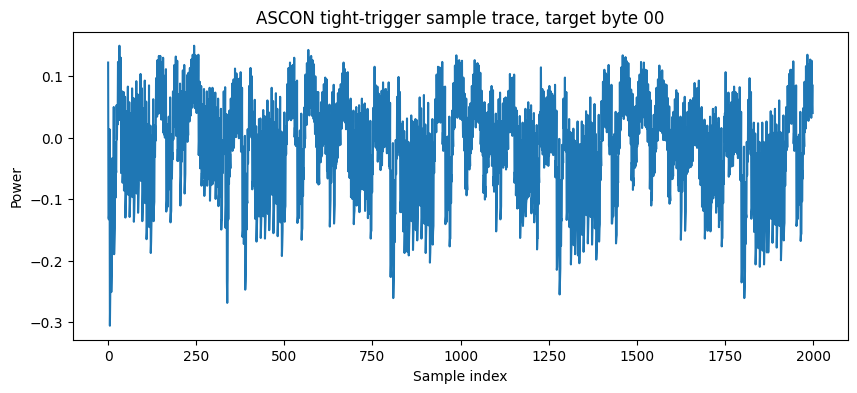

output: a0
trigger count: 332
trace length: 2000


In [6]:
# Cell 6 - Optional quick plot of one ASCON tight-trigger trace

import matplotlib.pyplot as plt

sample = capture_ascon_keybyte_trace(target_byte=0, timeout=1.0, debug=False)
wave = sample["wave"]

if wave is None:
    raise RuntimeError("No wave captured for plotting.")

plt.figure(figsize=(10, 4))
plt.plot(wave)
plt.title("ASCON tight-trigger sample trace, target byte 00")
plt.xlabel("Sample index")
plt.ylabel("Power")
plt.show()

print("output:", None if sample["out"] is None else sample["out"].hex())
print("trigger count:", sample["trig"])
print("trace length:", len(wave))

In [7]:
# Cell 7 - Save collection configuration

config = {
    "algorithm": "ASCON-AEAD-128",
    "project_dir": str(PROJECT_DIR),
    "firmware_dir": str(FW_DIR),
    "hex_path": str(HEX_PATH),
    "out_dir": str(OUT_DIR),
    "platform": PLATFORM,
    "ss_ver": SS_VER,
    "test_mode": TEST_MODE,
    "n_traces_per_byte": N_TRACES_PER_BYTE,
    "chunk_size": CHUNK_SIZE,
    "target_bytes": TARGET_BYTES,
    "trace_len": TRACE_LEN,
    "key_len": KEY_LEN,
    "nonce_len": NONCE_LEN,
    "random_nonce_per_trace": RANDOM_NONCE_PER_TRACE,
    "fixed_nonce_hex": FIXED_NONCE.hex(),
    "resp_len_keybyte": RESP_LEN_KEYBYTE,
    "created_at": datetime.now().isoformat(),
    "method": "random key per trace, fixed/random nonce, selectable target byte 0..15, ASCON tight-trigger key-byte capture",
}

config_path = OUT_DIR / "collection_config.json"
config_path.write_text(json.dumps(config, indent=2), encoding="utf-8")

print("Saved config:", config_path)
print(json.dumps(config, indent=2))

Saved config: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\tight_trigger_keybyte_auto30k\ascon_tighttrigger_30k_per_byte_20260526_014007\collection_config.json
{
  "algorithm": "ASCON-AEAD-128",
  "project_dir": "C:\\Users\\thetp\\Downloads\\ASCON_FYP",
  "firmware_dir": "C:\\Users\\thetp\\Downloads\\ASCON_FYP\\01_Firmware\\tight_trigger_keybyte\\simpleserial-ascon-keyabsorb",
  "hex_path": "C:\\Users\\thetp\\Downloads\\ASCON_FYP\\01_Firmware\\tight_trigger_keybyte\\simpleserial-ascon-keyabsorb\\simpleserial-ascon-keyabsorb-CWLITEXMEGA.hex",
  "out_dir": "C:\\Users\\thetp\\Downloads\\ASCON_FYP\\03_Data\\tight_trigger_keybyte_auto30k\\ascon_tighttrigger_30k_per_byte_20260526_014007",
  "platform": "CWLITEXMEGA",
  "ss_ver": "SS_VER_1_1",
  "test_mode": false,
  "n_traces_per_byte": 30000,
  "chunk_size": 1000,
  "target_bytes": [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15
  ],
  "trace_len": 2000,
  "key_len": 16,
 

In [8]:
# Cell 8 - Chunk saving and resume helpers


def get_existing_metadata_count(target_byte):
    byte_dir = OUT_DIR / f"byte_{target_byte:02d}"
    if not byte_dir.exists():
        return 0

    total_rows = 0
    for csv_path in sorted(byte_dir.glob(f"byte{target_byte:02d}_chunk_*_metadata.csv")):
        try:
            total_rows += len(pd.read_csv(csv_path))
        except Exception as e:
            print("Could not read", csv_path, e)
    return total_rows


def get_next_chunk_index(target_byte):
    byte_dir = OUT_DIR / f"byte_{target_byte:02d}"
    if not byte_dir.exists():
        return 0

    existing = sorted(byte_dir.glob(f"byte{target_byte:02d}_chunk_*_metadata.csv"))
    if not existing:
        return 0

    indices = []
    for p in existing:
        m = re.search(r"chunk_(\d+)_metadata\.csv", p.name)
        if m:
            indices.append(int(m.group(1)))
    return max(indices) + 1 if indices else 0


def save_byte_chunk(target_byte, chunk_index, traces, metadata_rows):
    byte_dir = OUT_DIR / f"byte_{target_byte:02d}"
    byte_dir.mkdir(parents=True, exist_ok=True)

    traces_arr = np.asarray(traces, dtype=np.float32)

    npz_path = byte_dir / f"byte{target_byte:02d}_chunk_{chunk_index:04d}_traces.npz"
    csv_path = byte_dir / f"byte{target_byte:02d}_chunk_{chunk_index:04d}_metadata.csv"

    if npz_path.exists() or csv_path.exists():
        raise FileExistsError(f"Refusing to overwrite existing chunk: {npz_path} or {csv_path}")

    if DRY_RUN_NO_SAVE:
        print("DRY RUN: not saving", npz_path, csv_path)
        return

    np.savez_compressed(npz_path, traces=traces_arr)
    pd.DataFrame(metadata_rows).to_csv(csv_path, index=False)

    print(f"Saved byte {target_byte:02d} chunk {chunk_index:04d}: {traces_arr.shape}")

In [9]:
# Cell 9 - Collection functions


def make_metadata_row(target_byte, trace_index, attempt_index, result):
    key_bytes = result["key_bytes"]
    nonce_bytes = result["nonce_bytes"]
    key_byte_value = result["key_byte_value"]
    bits = result["bits"]

    row = {
        "algorithm": "ASCON-AEAD-128",
        "target_byte": int(target_byte),
        "trace_index": int(trace_index),
        "attempt_index": int(attempt_index),
        "key_hex": key_bytes.hex(),
        "nonce_hex": nonce_bytes.hex(),
        "key_byte_value": int(key_byte_value),
        "key_byte_hex": f"{key_byte_value:02x}",
        "key_byte_hw": int(result["key_byte_hw"]),
        "output_hex": None if result["out"] is None else result["out"].hex(),
        "trigger_count": result["trig"],
        "capture_ret": bool(result["capture_ret"]),
        "raw_text": result["raw_text"],
    }

    for b, bit in enumerate(bits):
        row[f"bit{b}_lsb"] = int(bit)

    return row


def collect_target_byte(target_byte, n_traces):
    byte_dir = OUT_DIR / f"byte_{target_byte:02d}"
    byte_dir.mkdir(parents=True, exist_ok=True)

    existing_count = get_existing_metadata_count(target_byte) if RESUME_EXISTING else 0
    chunk_index = get_next_chunk_index(target_byte) if RESUME_EXISTING else 0

    if existing_count >= n_traces:
        print(f"Byte {target_byte:02d} already has {existing_count} traces. Skipping.")
        return {
            "target_byte": int(target_byte),
            "requested": int(n_traces),
            "existing": int(existing_count),
            "collected_new": 0,
            "collected_total": int(existing_count),
            "errors": 0,
            "skipped": True,
            "byte_dir": str(byte_dir),
        }

    print(f"Byte {target_byte:02d}: existing_count={existing_count}, next_chunk_index={chunk_index}")

    traces = []
    metadata_rows = []
    errors = []

    collected_total = existing_count
    collected_new = 0
    attempts = 0
    max_attempts = (n_traces - existing_count) * 4

    pbar = tqdm(total=n_traces, initial=existing_count, desc=f"ASCON BYTE {target_byte:02d}")

    while collected_total < n_traces and attempts < max_attempts:
        attempts += 1

        key_bytes = random_bytes(KEY_LEN)
        nonce_bytes = random_bytes(NONCE_LEN) if RANDOM_NONCE_PER_TRACE else FIXED_NONCE

        try:
            result = capture_ascon_keybyte_trace(
                target_byte=target_byte,
                key_bytes=key_bytes,
                nonce_bytes=nonce_bytes,
                timeout=0.7,
                debug=False,
            )

            wave = result["wave"]
            trig = result["trig"]
            out = result["out"]
            capture_ret = result["capture_ret"]

            valid = True
            reason = ""

            if capture_ret:
                valid = False
                reason = "scope_capture_timeout"
            elif wave is None:
                valid = False
                reason = "no_wave"
            elif len(wave) != TRACE_LEN:
                valid = False
                reason = f"wrong_trace_len_{len(wave)}"
            elif trig == 0:
                valid = False
                reason = "trigger_count_zero"
            elif out is None or len(out) != RESP_LEN_KEYBYTE:
                valid = False
                reason = "missing_or_wrong_response"
            elif not np.all(np.isfinite(wave)):
                valid = False
                reason = "non_finite_wave"

            if not valid:
                errors.append({
                    "target_byte": int(target_byte),
                    "attempt_index": int(attempts),
                    "reason": reason,
                    "trigger_count": trig,
                    "capture_ret": capture_ret,
                    "output_hex": None if out is None else out.hex(),
                })
                continue

            trace_index = collected_total
            metadata_rows.append(make_metadata_row(target_byte, trace_index, attempts, result))
            traces.append(wave)

            collected_total += 1
            collected_new += 1
            pbar.update(1)

            # Save chunk.
            if len(traces) >= CHUNK_SIZE:
                save_byte_chunk(target_byte, chunk_index, traces, metadata_rows)
                chunk_index += 1
                traces = []
                metadata_rows = []

                # Save errors frequently too.
                err_path = byte_dir / f"byte{target_byte:02d}_collection_errors.json"
                err_path.write_text(json.dumps(errors, indent=2), encoding="utf-8")
                gc.collect()

        except KeyboardInterrupt:
            print("KeyboardInterrupt detected. Saving partial chunk before stopping...")
            break
        except Exception as e:
            errors.append({
                "target_byte": int(target_byte),
                "attempt_index": int(attempts),
                "reason": "exception",
                "error": repr(e),
            })
            time.sleep(0.05)

    pbar.close()

    # Save final partial chunk.
    if len(traces) > 0:
        save_byte_chunk(target_byte, chunk_index, traces, metadata_rows)
        chunk_index += 1

    summary = {
        "target_byte": int(target_byte),
        "requested": int(n_traces),
        "existing_before": int(existing_count),
        "collected_new": int(collected_new),
        "collected_total": int(collected_total),
        "attempts": int(attempts),
        "errors": int(len(errors)),
        "chunk_size": int(CHUNK_SIZE),
        "chunks_after": int(chunk_index),
        "byte_dir": str(byte_dir),
        "finished_at": datetime.now().isoformat(),
    }

    summary_path = byte_dir / f"byte{target_byte:02d}_collection_summary.json"
    summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")

    errors_path = byte_dir / f"byte{target_byte:02d}_collection_errors.json"
    errors_path.write_text(json.dumps(errors, indent=2), encoding="utf-8")

    print("\nByte summary:")
    print(json.dumps(summary, indent=2))
    print("Saved summary:", summary_path)
    print("Saved errors:", errors_path)

    return summary

## 10. Run Automated Collection

This cell collects traces for all target bytes in `TARGET_BYTES`.

For full collection, this is:

```text
30,000 traces per byte × 16 bytes = 480,000 traces
```

The notebook saves chunk by chunk so it can resume if interrupted.

In [10]:
# Cell 10 - Run ASCON automated collection for bytes 0 to 15

all_summaries = []
start_time = time.time()

for target_byte in TARGET_BYTES:
    print("\n" + "=" * 80)
    print(f"STARTING ASCON TARGET_BYTE {target_byte:02d}")
    print("=" * 80)

    summary = collect_target_byte(target_byte, N_TRACES_PER_BYTE)
    all_summaries.append(summary)

    summary_path = OUT_DIR / "all_bytes_collection_summary_so_far.json"
    summary_path.write_text(json.dumps(all_summaries, indent=2), encoding="utf-8")

elapsed_hours = (time.time() - start_time) / 3600.0

final_summary = {
    "algorithm": "ASCON-AEAD-128",
    "n_traces_per_byte": int(N_TRACES_PER_BYTE),
    "target_bytes": TARGET_BYTES,
    "total_requested": int(N_TRACES_PER_BYTE * len(TARGET_BYTES)),
    "total_collected": int(sum(s.get("collected_total", 0) for s in all_summaries)),
    "total_new_collected": int(sum(s.get("collected_new", 0) for s in all_summaries)),
    "total_errors": int(sum(s.get("errors", 0) for s in all_summaries)),
    "elapsed_hours": float(elapsed_hours),
    "out_dir": str(OUT_DIR),
    "finished_at": datetime.now().isoformat(),
    "summaries": all_summaries,
}

final_summary_path = OUT_DIR / "final_collection_summary.json"
final_summary_path.write_text(json.dumps(final_summary, indent=2), encoding="utf-8")

print("\nALL TARGET BYTES FINISHED.")
print(json.dumps(final_summary, indent=2))
print("Saved final summary:", final_summary_path)


STARTING ASCON TARGET_BYTE 00
Byte 00: existing_count=0, next_chunk_index=0


ASCON BYTE 00:   0%|          | 0/30000 [00:00<?, ?it/s]

Saved byte 00 chunk 0000: (1000, 2000)
Saved byte 00 chunk 0001: (1000, 2000)
Saved byte 00 chunk 0002: (1000, 2000)
Saved byte 00 chunk 0003: (1000, 2000)
Saved byte 00 chunk 0004: (1000, 2000)
Saved byte 00 chunk 0005: (1000, 2000)
Saved byte 00 chunk 0006: (1000, 2000)
Saved byte 00 chunk 0007: (1000, 2000)
Saved byte 00 chunk 0008: (1000, 2000)
Saved byte 00 chunk 0009: (1000, 2000)
Saved byte 00 chunk 0010: (1000, 2000)
Saved byte 00 chunk 0011: (1000, 2000)
Saved byte 00 chunk 0012: (1000, 2000)
Saved byte 00 chunk 0013: (1000, 2000)
Saved byte 00 chunk 0014: (1000, 2000)
Saved byte 00 chunk 0015: (1000, 2000)
Saved byte 00 chunk 0016: (1000, 2000)
Saved byte 00 chunk 0017: (1000, 2000)
Saved byte 00 chunk 0018: (1000, 2000)
Saved byte 00 chunk 0019: (1000, 2000)
Saved byte 00 chunk 0020: (1000, 2000)
Saved byte 00 chunk 0021: (1000, 2000)
Saved byte 00 chunk 0022: (1000, 2000)
Saved byte 00 chunk 0023: (1000, 2000)
Saved byte 00 chunk 0024: (1000, 2000)
Saved byte 00 chunk 0025:

ASCON BYTE 01:   0%|          | 0/30000 [00:00<?, ?it/s]

Saved byte 01 chunk 0000: (1000, 2000)
Saved byte 01 chunk 0001: (1000, 2000)
Saved byte 01 chunk 0002: (1000, 2000)
Saved byte 01 chunk 0003: (1000, 2000)
Saved byte 01 chunk 0004: (1000, 2000)
Saved byte 01 chunk 0005: (1000, 2000)
Saved byte 01 chunk 0006: (1000, 2000)
Saved byte 01 chunk 0007: (1000, 2000)
Saved byte 01 chunk 0008: (1000, 2000)
Saved byte 01 chunk 0009: (1000, 2000)
Saved byte 01 chunk 0010: (1000, 2000)
Saved byte 01 chunk 0011: (1000, 2000)
Saved byte 01 chunk 0012: (1000, 2000)
Saved byte 01 chunk 0013: (1000, 2000)
Saved byte 01 chunk 0014: (1000, 2000)
Saved byte 01 chunk 0015: (1000, 2000)
Saved byte 01 chunk 0016: (1000, 2000)
Saved byte 01 chunk 0017: (1000, 2000)
Saved byte 01 chunk 0018: (1000, 2000)
Saved byte 01 chunk 0019: (1000, 2000)
Saved byte 01 chunk 0020: (1000, 2000)
Saved byte 01 chunk 0021: (1000, 2000)
Saved byte 01 chunk 0022: (1000, 2000)
Saved byte 01 chunk 0023: (1000, 2000)
Saved byte 01 chunk 0024: (1000, 2000)
Saved byte 01 chunk 0025:

...

Saved byte 13 chunk 0000: (1000, 2000)
Saved byte 13 chunk 0001: (1000, 2000)
Saved byte 13 chunk 0002: (1000, 2000)
Saved byte 13 chunk 0003: (1000, 2000)
Saved byte 13 chunk 0004: (1000, 2000)
Saved byte 13 chunk 0005: (1000, 2000)
Saved byte 13 chunk 0006: (1000, 2000)
Saved byte 13 chunk 0007: (1000, 2000)
Saved byte 13 chunk 0008: (1000, 2000)
Saved byte 13 chunk 0009: (1000, 2000)
Saved byte 13 chunk 0010: (1000, 2000)
Saved byte 13 chunk 0011: (1000, 2000)
Saved byte 13 chunk 0012: (1000, 2000)
Saved byte 13 chunk 0013: (1000, 2000)
Saved byte 13 chunk 0014: (1000, 2000)
Saved byte 13 chunk 0015: (1000, 2000)
Saved byte 13 chunk 0016: (1000, 2000)
Saved byte 13 chunk 0017: (1000, 2000)
Saved byte 13 chunk 0018: (1000, 2000)
Saved byte 13 chunk 0019: (1000, 2000)
Saved byte 13 chunk 0020: (1000, 2000)
Saved byte 13 chunk 0021: (1000, 2000)
Saved byte 13 chunk 0022: (1000, 2000)
Saved byte 13 chunk 0023: (1000, 2000)
Saved byte 13 chunk 0024: (1000, 2000)
Saved byte 13 chunk 0025:

ASCON BYTE 14:   0%|          | 0/30000 [00:00<?, ?it/s]

Saved byte 14 chunk 0000: (1000, 2000)
Saved byte 14 chunk 0001: (1000, 2000)
Saved byte 14 chunk 0002: (1000, 2000)
Saved byte 14 chunk 0003: (1000, 2000)
Saved byte 14 chunk 0004: (1000, 2000)
Saved byte 14 chunk 0005: (1000, 2000)
Saved byte 14 chunk 0006: (1000, 2000)
Saved byte 14 chunk 0007: (1000, 2000)
Saved byte 14 chunk 0008: (1000, 2000)
Saved byte 14 chunk 0009: (1000, 2000)
Saved byte 14 chunk 0010: (1000, 2000)
Saved byte 14 chunk 0011: (1000, 2000)
Saved byte 14 chunk 0012: (1000, 2000)
Saved byte 14 chunk 0013: (1000, 2000)
Saved byte 14 chunk 0014: (1000, 2000)
Saved byte 14 chunk 0015: (1000, 2000)
Saved byte 14 chunk 0016: (1000, 2000)
Saved byte 14 chunk 0017: (1000, 2000)
Saved byte 14 chunk 0018: (1000, 2000)
Saved byte 14 chunk 0019: (1000, 2000)
Saved byte 14 chunk 0020: (1000, 2000)
Saved byte 14 chunk 0021: (1000, 2000)
Saved byte 14 chunk 0022: (1000, 2000)
Saved byte 14 chunk 0023: (1000, 2000)
Saved byte 14 chunk 0024: (1000, 2000)
Saved byte 14 chunk 0025:

ASCON BYTE 15:   0%|          | 0/30000 [00:00<?, ?it/s]

Saved byte 15 chunk 0000: (1000, 2000)
Saved byte 15 chunk 0001: (1000, 2000)
Saved byte 15 chunk 0002: (1000, 2000)
Saved byte 15 chunk 0003: (1000, 2000)
Saved byte 15 chunk 0004: (1000, 2000)
Saved byte 15 chunk 0005: (1000, 2000)
Saved byte 15 chunk 0006: (1000, 2000)
Saved byte 15 chunk 0007: (1000, 2000)
Saved byte 15 chunk 0008: (1000, 2000)
Saved byte 15 chunk 0009: (1000, 2000)
Saved byte 15 chunk 0010: (1000, 2000)
Saved byte 15 chunk 0011: (1000, 2000)
Saved byte 15 chunk 0012: (1000, 2000)
Saved byte 15 chunk 0013: (1000, 2000)
Saved byte 15 chunk 0014: (1000, 2000)
Saved byte 15 chunk 0015: (1000, 2000)
Saved byte 15 chunk 0016: (1000, 2000)
Saved byte 15 chunk 0017: (1000, 2000)
Saved byte 15 chunk 0018: (1000, 2000)
Saved byte 15 chunk 0019: (1000, 2000)
Saved byte 15 chunk 0020: (1000, 2000)
Saved byte 15 chunk 0021: (1000, 2000)
Saved byte 15 chunk 0022: (1000, 2000)
Saved byte 15 chunk 0023: (1000, 2000)
Saved byte 15 chunk 0024: (1000, 2000)
Saved byte 15 chunk 0025:

In [11]:
# Cell 11 - Verify saved ASCON dataset structure

rows = []

for byte_dir in sorted(OUT_DIR.glob("byte_*")):
    if not byte_dir.is_dir():
        continue

    target_byte = int(byte_dir.name.split("_")[1])
    trace_files = sorted(byte_dir.glob(f"byte{target_byte:02d}_chunk_*_traces.npz"))
    meta_files = sorted(byte_dir.glob(f"byte{target_byte:02d}_chunk_*_metadata.csv"))

    n_trace_rows = 0
    shapes = []
    bad_trace_files = []

    for tf in trace_files:
        try:
            arr = np.load(tf)["traces"]
            shapes.append(tuple(arr.shape))
            n_trace_rows += arr.shape[0]
            if arr.ndim != 2 or arr.shape[1] != TRACE_LEN:
                bad_trace_files.append(str(tf))
            if not np.all(np.isfinite(arr)):
                bad_trace_files.append(str(tf) + " non_finite")
        except Exception as e:
            shapes.append(("ERROR", str(e)))
            bad_trace_files.append(str(tf))

    n_meta_rows = 0
    metadata_target_ok = True
    metadata_label_ok = True
    bit_cols_ok = True
    trigger_positive_count = 0

    for mf in meta_files:
        try:
            mdf = pd.read_csv(mf)
            n_meta_rows += len(mdf)

            if "target_byte" in mdf.columns:
                metadata_target_ok = metadata_target_ok and bool((mdf["target_byte"] == target_byte).all())
            else:
                metadata_target_ok = False

            required_cols = ["key_hex", "key_byte_value", "key_byte_hex", "key_byte_hw"] + [f"bit{i}_lsb" for i in range(8)]
            bit_cols_ok = bit_cols_ok and all(c in mdf.columns for c in required_cols)

            if all(c in mdf.columns for c in ["key_hex", "key_byte_value"]):
                extracted = mdf["key_hex"].apply(lambda x: int(str(x)[2*target_byte:2*target_byte+2], 16))
                metadata_label_ok = metadata_label_ok and bool((extracted.values == mdf["key_byte_value"].values).all())
            else:
                metadata_label_ok = False

            if "trigger_count" in mdf.columns:
                trigger_positive_count += int((mdf["trigger_count"].fillna(0) > 0).sum())
        except Exception as e:
            metadata_target_ok = False
            metadata_label_ok = False
            bit_cols_ok = False

    rows.append({
        "target_byte": target_byte,
        "trace_files": len(trace_files),
        "metadata_files": len(meta_files),
        "trace_rows": int(n_trace_rows),
        "metadata_rows": int(n_meta_rows),
        "trace_meta_match": bool(n_trace_rows == n_meta_rows),
        "expected_rows_met": bool(n_trace_rows >= N_TRACES_PER_BYTE and n_meta_rows >= N_TRACES_PER_BYTE),
        "first_shape": shapes[0] if shapes else None,
        "metadata_target_ok": bool(metadata_target_ok),
        "metadata_label_ok": bool(metadata_label_ok),
        "bit_cols_ok": bool(bit_cols_ok),
        "trigger_positive_count": int(trigger_positive_count),
        "bad_trace_files_count": len(bad_trace_files),
        "byte_dir": str(byte_dir),
    })

verify_df = pd.DataFrame(rows).sort_values("target_byte") if rows else pd.DataFrame()
display(verify_df)

verify_path = OUT_DIR / "dataset_verification_summary.csv"
verify_df.to_csv(verify_path, index=False)
print("Saved verification summary:", verify_path)

,target_byte,trace_files,metadata_files,trace_rows,metadata_rows,trace_meta_match,expected_rows_met,first_shape,metadata_target_ok,metadata_label_ok,bit_cols_ok,trigger_positive_count,bad_trace_files_count,byte_dir
0,0,30,30,30000,30000,True,True,"(1000, 2000)",True,True,True,30000,0,C:\Users\thetp\Downloads\ASCON_FYP\03_Data\tig...
1,1,30,30,30000,30000,True,True,"(1000, 2000)",True,True,True,30000,0,C:\Users\thetp\Downloads\ASCON_FYP\03_Data\tig...
2,2,30,30,30000,30000,True,True,"(1000, 2000)",True,True,True,30000,0,C:\Users\thetp\Downloads\ASCON_FYP\03_Data\tig...
3,3,30,30,30000,30000,True,True,"(1000, 2000)",True,True,True,30000,0,C:\Users\thetp\Downloads\ASCON_FYP\03_Data\tig...
4,4,30,30,30000,30000,True,True,"(1000, 2000)",True,True,True,30000,0,C:\Users\thetp\Downloads\ASCON_FYP\03_Data\tig...
5,5,30,30,30000,30000,True,True,"(1000, 2000)",True,True,True,30000,0,C:\Users\thetp\Downloads\ASCON_FYP\03_Data\tig...
6,6,30,30,30000,30000,True,True,"(1000, 2000)",True,True,True,30000,0,C:\Users\thetp\Downloads\ASCON_FYP\03_Data\tig...
7,7,30,30,30000,30000,True,True,"(1000, 2000)",True,True,True,30000,0,C:\Users\thetp\Downloads\ASCON_FYP\03_Data\tig...
8,8,30,30,30000,30000,True,True,"(1000, 2000)",True,True,True,30000,0,C:\Users\thetp\Downloads\ASCON_FYP\03_Data\tig...
9,9,30,30,30000,30000,True,True,"(1000, 2000)",True,True,True,30000,0,C:\Users\thetp\Downloads\ASCON_FYP\03_Data\tig...


Saved verification summary: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\tight_trigger_keybyte_auto30k\ascon_tighttrigger_30k_per_byte_20260526_014007\dataset_verification_summary.csv


In [12]:
# Cell 12 - Disconnect cleanly after collection

try:
    target.dis()
except Exception:
    pass

try:
    scope.dis()
except Exception:
    pass

print("Disconnected ChipWhisperer scope and target.")

Disconnected ChipWhisperer scope and target.
